#**UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA**

**ESPECIALIZACIÓN EN CIENCIA DE DATOS Y ANALÍTICA**

### CURSO: MÉTODOS ESTADÍSTICOS EN LA CIENCIA DE DATOS Y ANALÍTICA
### Fase: Intermedia, Tarea 2, Análisis Exploratorio e Inferencial

#### Estudiante: MARIA VIRGINIA GÓMEZ SANDOVAL
Grupo: 203008072_5

Mayo 2026


#  Objetivos Específicos
Explicar el comportamiento de las variables del servicio de transporte mediante técnica descriptiva e inferiencial, usando la base de datos de Dynamic_pricing.csv, que permitan decisiones sobre duración de viajes esperados, calificaciones y segmentación de clientes.

## Objetivos Genreales
* Identificar la distribución de la variable Expected_ride_Duration (Trip_Distance), mediante el empleo del teorema central del límite y sus características para inferir el comportamientos de la población.

* Comparar variables del categóricas y cuantitativas mediante separación de grupos, para reconocer asociaciones entre lealtad del cliente, tipo de vehículo, calificación y duración del viaje.

* Perfilar parámetros poblacionales y contrastar hipótesis con intervalos de confianza y pruebas estadísticas, para apoyar decisiones organizacionales con evidencia cuantitativa.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## 1. Carga del Dataset Dynamic_pricing.csv

In [ ]:
# 0) Cargar datos
df = pd.read_csv("/content/drive/MyDrive/ESPECIALIZACIÓN/MÉTODOS ESTADISTICOS/Anexo 1 - Base de Datos dynamic_pricing.csv")
print(df.shape)

(1000, 10)


In [ ]:
df.head(1)

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273


In [ ]:
print(df.info())

2.1 Teorema Central del Límite (TCL) y su aplicación práctica:

• Simular múltiples muestras de la variable Trip_Distance (por ejemplo,
n=30, repetidas 1000 veces).

• Graficar la distribución de las medias muestrales.

• Verificar empíricamente la forma aproximadamente normal de la
distribución muestral.

• Explicar cómo el TCL justifica el uso de modelos inferenciales para
estimar parámetros poblacionales.



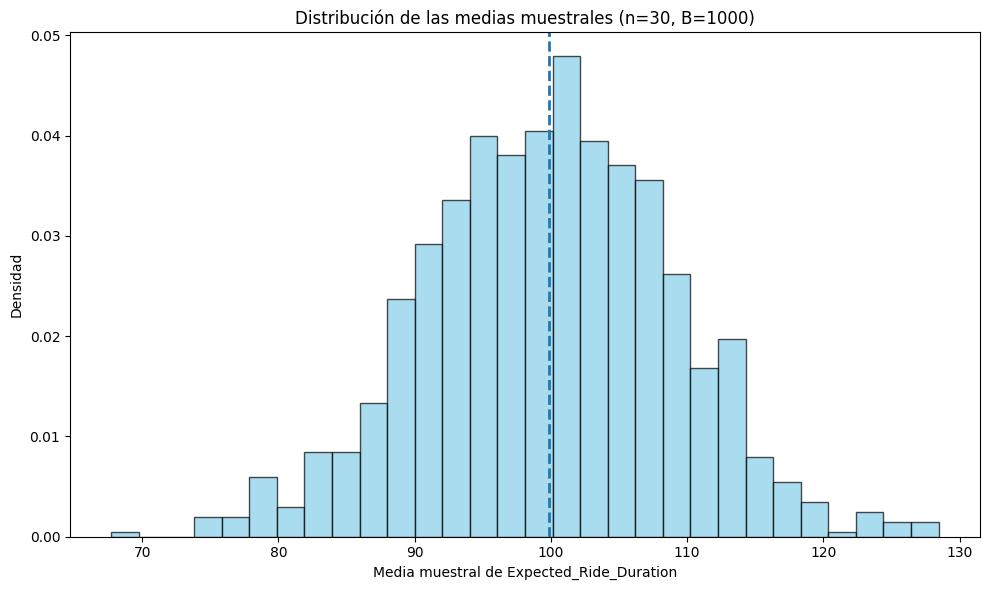

Media poblacional de Expected_Ride_Duration: 99.59
Desviación estándar poblacional de Expected_Ride_Duration: 49.17
Media de las medias muestrales: 99.84
Desviación estándar de las medias muestrales: 9.11


In [ ]:
# Definir nombres de variables
col_duration = 'Expected_Ride_Duration'
col_rating = 'Average_Ratings'

# 1) Teorema Central del Límite (TCL)
#    Simular 1000 muestras de tamaño n=30 de Expected_Ride_Duration
n = 30      # tamaño de cada muestra
B = 1000    # número de repeticiones

np.random.seed(42)
sample_means = []

for i in range(B):
    # muestra aleatoria con reemplazo
    sample = df[col_duration].sample(n, replace=True)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)

# Guardar las medias en un CSV (opcional, para revisarlas)
clt_df = pd.DataFrame({'sample_mean_duration': sample_means})
clt_df.to_csv('clt_sample_means.csv', index=False)

# Graficar la distribución de las medias muestrales
plt.figure(figsize=(10, 6))
plt.hist(sample_means, bins=30, density=True, alpha=0.7,
         color='skyblue', edgecolor='black')
plt.axvline(sample_means.mean(), linestyle="--", linewidth=2, label="Media de medias")
plt.title('Distribución de las medias muestrales (n=30, B=1000)')
plt.xlabel('Media muestral de Expected_Ride_Duration')
plt.ylabel('Densidad')
plt.tight_layout()
plt.savefig('clt_sample_means.png', dpi=300)
plt.show()

print(f'Media poblacional de Expected_Ride_Duration: {df[col_duration].mean():.2f}')
print(f'Desviación estándar poblacional de Expected_Ride_Duration: {df[col_duration].std():.2f}')
print(f'Media de las medias muestrales: {sample_means.mean():.2f}')
print(f'Desviación estándar de las medias muestrales: {sample_means.std():.2f}')


### Verificación Shapiro-Wilk sobre las medias muestrales

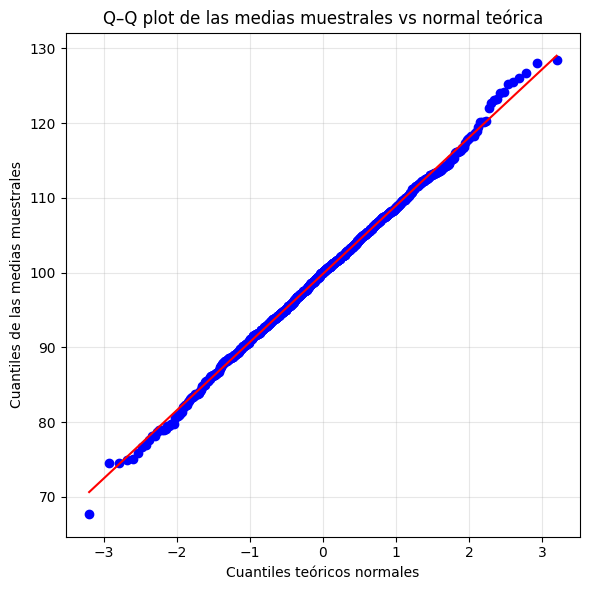

Shapiro-Wilk W: 0.9986848384770395
p-valor: 0.6783342254675786
Conclusión: no se rechaza H0, los datos son compatibles con la normalidad.


In [ ]:
from scipy import stats

# sample_means debe ser un array/lista con las 1000 medias muestrales
# por ejemplo, obtenido de la simulación del TCL


plt.figure(figsize=(6, 6))
stats.probplot(sample_means, dist="norm", plot=plt)
plt.title("Q–Q plot de las medias muestrales vs normal teórica")
plt.xlabel("Cuantiles teóricos normales")
plt.ylabel("Cuantiles de las medias muestrales")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

statistic, p_value = stats.shapiro(sample_means)

print("Shapiro-Wilk W:", statistic)
print("p-valor:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Conclusión: se rechaza H0, los datos NO parecen normales.")
else:
    print("Conclusión: no se rechaza H0, los datos son compatibles con la normalidad.")

Gracias al Teorema Central del Límite (TCL), podemos utilizar modelos inferenciales basados en la normalidad, ya que, bajo ciertas condiciones - que se cumplen al realizar el procedimiento en este análisis -, la distribución de las medias muestrales tiende a aproximarse a una distribución normal, independientemente de la forma de la distribución original de la población.Esto permite que aunque las muestras cambien, las medias muestrales siguen un patrón predecible. Con el qué, al contar con una muestra significativa podemos inferir, a partir de ella, información que permita realizar estimaciones y tomar decisiones sobre el comportamiento de la población en general.

Para verificar empíricamente que efectivamentela distribución de las medias muestrales en este ejercicio, es aproximadamente normal, primero se generó 1000 medias de muestras de tamaño 30 y se construyó un histograma. La forma del histograma es claramente campaniforme y simétrica alrededor de la media.

Además, se realizó el gráfico Q-Q  para verificar que los cuantiles de las muestras y los cuantiles de la distribución cohincidan con una relación directa. Por otro lado, también apliqué la prueba de normalidad de Shapiro‑Wilk sobre esas medias y obtuve un p‑valor mayor que 0.05, por lo que **no** rechazo la hipótesis de normalidad. Estas dos evidencias, gráfica y numérica, son coherentes con el Teorema Central del Límite y respaldan que la distribución muestral se aproxima a una normal.


## 2.2 Intervalos de Confianza (IC)
• Calcular:

* IC del 95% para la media de Trip_Distance.

* IC del 95% para la proporción de Trip_Rating excelente (≥4).

* IC del 95% para la varianza de Trip_Distance.

• Interpretar cada uno de los intervalos, señalando su utilidad para la
toma de decisiones.

In [ ]:
# 2) Intervalos de confianza (IC) al 95 %

alpha = 0.05

# 2.1 IC 95% para la MEDIA de Expected_Ride_Duration
x = df[col_duration].values
n_pop = len(x)
mean_x = np.mean(x)
std_x = np.std(x, ddof=1)
se_mean = std_x / np.sqrt(n_pop)

t_crit = stats.t.ppf(1 - alpha/2, df=n_pop - 1)
ci_mean_lower = mean_x - t_crit * se_mean
ci_mean_upper = mean_x + t_crit * se_mean

print('IC 95% para la media de Trip_distance:')
print(f'Media muestral = {mean_x:.2f}')
print(f'[{ci_mean_lower:.2f}, {ci_mean_upper:.2f}]')


# 2.2 IC 95% para la PROPORCIÓN de ratings excelentes (Average_Ratings >= 4)
y = df[col_rating].values
excellent = (y >= 4).astype(int)
phat = excellent.mean()

z_crit = stats.norm.ppf(1 - alpha/2)
se_p = np.sqrt(phat * (1 - phat) / n_pop)
ci_p_lower = phat - z_crit * se_p
ci_p_upper = phat + z_crit * se_p

print('\nIC 95% para la proporción de Trip_Rating excelentes (>=4):')
print(f'Proporción muestral de calificaciones exelentes = {phat:.3f}')
print(f'[{ci_p_lower:.3f}, {ci_p_upper:.3f}]')

# 2.3 IC 95% para la VARIANZA de Expected_Ride_Duration (chi-cuadrado)
var_x = std_x**2
chi2_lower = stats.chi2.ppf(alpha/2, df=n_pop - 1)
chi2_upper = stats.chi2.ppf(1 - alpha/2, df=n_pop - 1)
ci_var_lower = (n_pop - 1) * var_x / chi2_upper
ci_var_upper = (n_pop - 1) * var_x / chi2_lower

print('\nIC 95% para la varianza de Expected_Ride_Duration:')
print(f'Varianza muestral = {var_x:.2f}')
print(f'[{ci_var_lower:.2f}, {ci_var_upper:.2f}]')

IC 95% para la media de Trip_distance:
Media muestral = 99.59
[96.54, 102.64]

IC 95% para la proporción de Trip_Rating excelentes (>=4):
Proporción muestral de calificaciones exelentes = 0.686
[0.657, 0.715]

IC 95% para la varianza de Expected_Ride_Duration:
Varianza muestral = 2417.24
[2218.51, 2644.06]


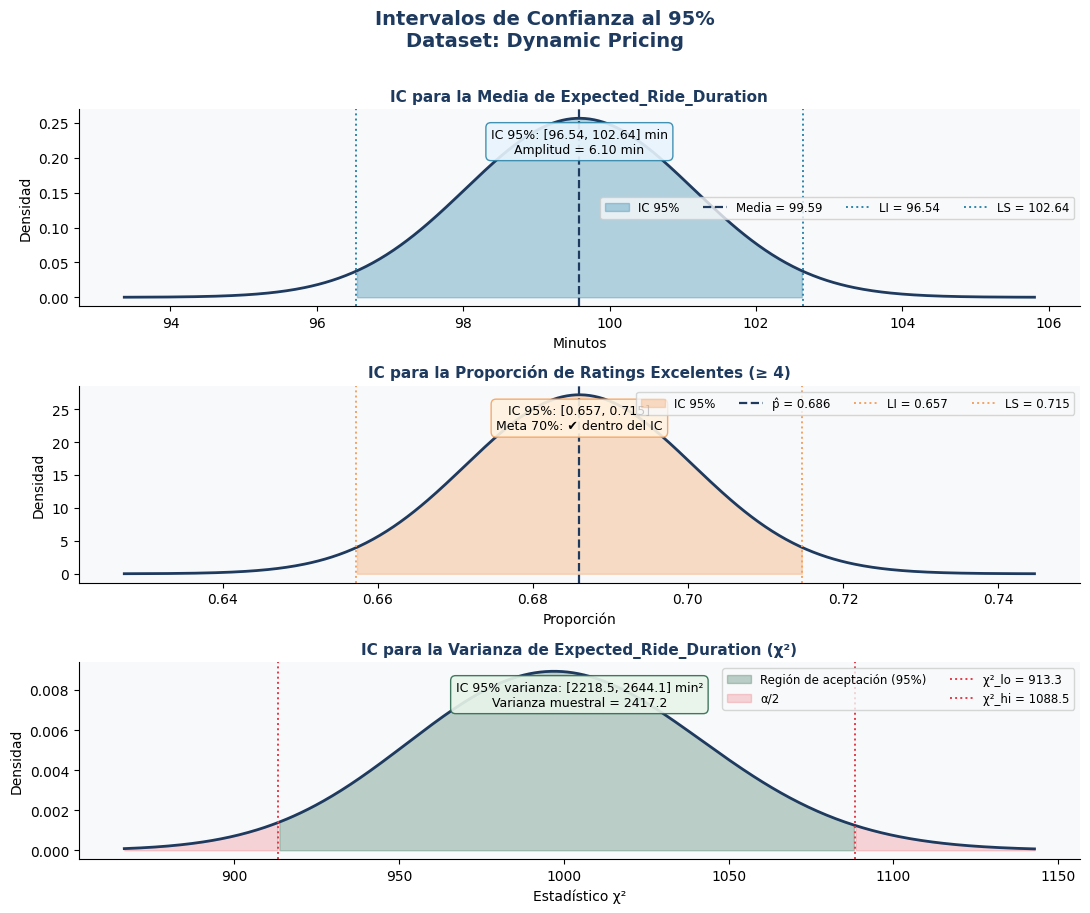

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.patches as mpatches


# ── Cálculo de los ICs ──────────────────────────────────────────
x      = df[col_duration].values
n_pop  = len(x)
mean_x = np.mean(x)
std_x  = np.std(x, ddof=1)
se     = std_x / np.sqrt(n_pop)
t_c    = stats.t.ppf(1 - alpha/2, df=n_pop - 1)
ic_mean = (mean_x - t_c * se, mean_x + t_c * se)

y       = df[col_rating].values
phat    = (y >= 4).mean()
z_c     = stats.norm.ppf(1 - alpha/2)
se_p    = np.sqrt(phat * (1 - phat) / n_pop)
ic_prop = (phat - z_c * se_p, phat + z_c * se_p)

var_x    = std_x ** 2
chi2_lo  = stats.chi2.ppf(alpha/2,     df=n_pop - 1)
chi2_hi  = stats.chi2.ppf(1 - alpha/2, df=n_pop - 1)
ic_var   = ((n_pop - 1) * var_x / chi2_hi,
            (n_pop - 1) * var_x / chi2_lo)

# ── Paleta de colores ───────────────────────────────────────────
C_NAVY  = '#1E3A5F'
C_TEAL  = '#2E86AB'
C_ORG   = '#F4A261'
C_GRN   = '#2D6A4F'
BG      = '#F8F9FA'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.facecolor': BG,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Figura principal ────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(11, 9))
fig.suptitle('Intervalos de Confianza al 95%\nDataset: Dynamic Pricing',
             fontsize=14, fontweight='bold', color=C_NAVY, y=1.01)

# ── Panel 1: IC para la Media ───────────────────────────────────
ax = axes[0]
x_vals = np.linspace(mean_x - 4*se, mean_x + 4*se, 400)
ax.fill_between(x_vals,
    stats.norm.pdf(x_vals, mean_x, se),
    where=(x_vals >= ic_mean[0]) & (x_vals <= ic_mean[1]),
    alpha=0.35, color=C_TEAL, label='IC 95%')
ax.plot(x_vals, stats.norm.pdf(x_vals, mean_x, se),
       color=C_NAVY, lw=2)
ax.axvline(mean_x,       color=C_NAVY, lw=1.6, ls='--', label=f'Media = {mean_x:.2f}')
ax.axvline(ic_mean[0], color=C_TEAL,  lw=1.4, ls=':',  label=f'LI = {ic_mean[0]:.2f}')
ax.axvline(ic_mean[1], color=C_TEAL,  lw=1.4, ls=':',  label=f'LS = {ic_mean[1]:.2f}')
ax.set_title('IC para la Media de Expected_Ride_Duration',
            fontweight='bold', color=C_NAVY, fontsize=11)
ax.set_xlabel('Minutos'); ax.set_ylabel('Densidad')
ax.legend(fontsize=8.5, ncol=4)
ax.text(0.5, 0.78,
    f'IC 95%: [{ic_mean[0]:.2f}, {ic_mean[1]:.2f}] min\nAmplitud = {ic_mean[1]-ic_mean[0]:.2f} min',
    transform=ax.transAxes, ha='center', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', fc='#E8F4FD', ec=C_TEAL, alpha=0.9))

# ── Panel 2: IC para la Proporción de Ratings >= 4 ──────────────
ax = axes[1]
p_vals = np.linspace(phat - 4*se_p, phat + 4*se_p, 400)
ax.fill_between(p_vals,
    stats.norm.pdf(p_vals, phat, se_p),
    where=(p_vals >= ic_prop[0]) & (p_vals <= ic_prop[1]),
    alpha=0.35, color=C_ORG, label='IC 95%')
ax.plot(p_vals, stats.norm.pdf(p_vals, phat, se_p),
       color=C_NAVY, lw=2)
ax.axvline(phat,        color=C_NAVY, lw=1.6, ls='--', label=f'p̂ = {phat:.3f}')
ax.axvline(ic_prop[0], color=C_ORG,  lw=1.4, ls=':',  label=f'LI = {ic_prop[0]:.3f}')
ax.axvline(ic_prop[1], color=C_ORG,  lw=1.4, ls=':',  label=f'LS = {ic_prop[1]:.3f}')
ax.set_title('IC para la Proporción de Ratings Excelentes (≥ 4)',
            fontweight='bold', color=C_NAVY, fontsize=11)
ax.set_xlabel('Proporción'); ax.set_ylabel('Densidad')
ax.legend(fontsize=8.5, ncol=4)
ax.text(0.5, 0.78,
    f'IC 95%: [{ic_prop[0]:.3f}, {ic_prop[1]:.3f}]\nMeta 70%: {"✔ dentro del IC" if ic_prop[0] < 0.70 < ic_prop[1] else "fuera del IC"}',
    transform=ax.transAxes, ha='center', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', fc='#FFF3E0', ec=C_ORG, alpha=0.9))

# ── Panel 3: IC para la Varianza (Chi-cuadrado) ─────────────────
ax = axes[2]
df_chi = n_pop - 1
chi_rng = np.linspace(stats.chi2.ppf(0.001, df_chi),
                      stats.chi2.ppf(0.999, df_chi), 500)
chi_pdf = stats.chi2.pdf(chi_rng, df_chi)
ax.plot(chi_rng, chi_pdf, color=C_NAVY, lw=2)
ax.fill_between(chi_rng, chi_pdf,
    where=(chi_rng >= chi2_lo) & (chi_rng <= chi2_hi),
    alpha=0.30, color=C_GRN, label='Región de aceptación (95%)')
ax.fill_between(chi_rng, chi_pdf,
    where=(chi_rng < chi2_lo),
    alpha=0.20, color='#E63946', label='α/2')
ax.fill_between(chi_rng, chi_pdf,
    where=(chi_rng > chi2_hi),
    alpha=0.20, color='#E63946')
ax.axvline(chi2_lo, color='#E63946', lw=1.4, ls=':',
           label=f'χ²_lo = {chi2_lo:.1f}')
ax.axvline(chi2_hi, color='#E63946', lw=1.4, ls=':',
           label=f'χ²_hi = {chi2_hi:.1f}')
ax.set_title('IC para la Varianza de Expected_Ride_Duration (χ²)',
            fontweight='bold', color=C_NAVY, fontsize=11)
ax.set_xlabel('Estadístico χ²'); ax.set_ylabel('Densidad')
ax.legend(fontsize=8.5, ncol=2)
ax.text(0.5, 0.78,
    f'IC 95% varianza: [{ic_var[0]:.1f}, {ic_var[1]:.1f}] min²\nVarianza muestral = {var_x:.1f}',
    transform=ax.transAxes, ha='center', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', fc='#E8F5E9', ec=C_GRN, alpha=0.9))

plt.tight_layout()
plt.savefig('IC_dynamic_pricing.png', dpi=200, bbox_inches='tight')
plt.show()

### * **Utilidad para la toma de decisiones  Expected_Ride_Duration:**
Para la empresa, conocer este rango ayuda a planear recursos (vehículos, conductores) asumiendo que la mayoría de los viajes esperados promedian cerca de 100 minutos.
### * **Utilidad para decisiones: Average_Ratings >= 4**

Esta información sirve para evaluar la satisfacción de los clientes y fijar metas de calidad (por ejemplo, mantener la proporción de calificaciones excelentes por encima de 70%).

### * **Utilidad para decisiones: Expected_Ride_Duration**

Conocer la varianza ayuda a la empresa a entender cuánta variabilidad hay en la duración esperada de los viajes.

Se obtuvo una varianza alta (2218.51 y 2644.06) lo implica viajes muy dispersos o heterogeneos en duración, lo que complica la programación de conductores y los modelos de precios dinámicos.



# 2.3 Prueba de Hipótesis para Comparación de Grupos
* Aplicar:Prueba t para comparar la media de Trip_Distance entre clientes
con diferente Customer_Loyalty.
* Prueba t para diferencias de proporciones en Trip_Rating según tipo de vehículo (si la variable lo permite).

* Presentar hipótesis nula y alternativa, estadístico de prueba, p-valor y
conclusión.

H0: No existe diferencias significativas en la media de Trip_Distance entre los dos grupos de lealtad
H1: Sí existen diferencias significativas en la media de Trip_distance entre los dos grupos de lealtad.

In [ ]:
# Cargar datos
df = pd.read_csv("/content/drive/MyDrive/ESPECIALIZACIÓN/MÉTODOS ESTADISTICOS/Anexo 1 - Base de Datos dynamic_pricing.csv")
print
("Categorías de Customer_Loyalty_Status:")
print(df["Customer_Loyalty_Status"].value_counts())
print("\nCategorías de Vehicle_Type:")
print(df["Vehicle_Type"].value_counts())

Customer_Loyalty_Status
Silver     367
Regular    320
Gold       313
Name: count, dtype: int64

Categorías de Vehicle_Type:
Vehicle_Type
Premium    522
Economy    478
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Cargar datos
df = pd.read_csv("/content/drive/MyDrive/ESPECIALIZACIÓN/MÉTODOS ESTADISTICOS/Anexo 1 - Base de Datos dynamic_pricing.csv")

# Variables
col_y = 'Expected_Ride_Duration'       # reemplaza Trip_Distance
col_group = 'Customer_Loyalty_Status'  # Customer_Loyalty

# Definir dos grupos: Gold vs Silver
g1 = df[df[col_group] == 'Gold'][col_y].values   # grupo 1: Gold
g2 = df[df[col_group] == 'Silver'][col_y].values # grupo 2: Silver

# Prueba t de Student para dos muestras independientes (Welch)
t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)

print("\n=== PRUEBA T PARA DIFERENCIA DE GRUPOS ===")
print('n_regular =', len(g1), ' media_gold =', g1.mean())
print('n_silver =', len(g2), ' media_silver =', g2.mean())
print('t =', t_stat, '  p-valor =', p_val)

if 'Customer_Loyalty_Status' in df.columns:

    if p_val < 0.05:
        print("Conclusión: Se rechaza H0. Existe evidencia estadísticamente significativa de diferencia entre las medias.")
    else:
        print("Conclusión: No se rechaza H0. No existe evidencia suficiente para afirmar diferencias entre las medias.")

else:
    print("No se encontró la variable 'Customer_Loyalty_Status' en el DataFrame.")


# ==================================
# PRUEBA 2: Diferencia de proporciones
# Variable: Average_Ratings >= 4
# Gruós: Vehicle_Type
# ==================================

col_rating = 'Average_Ratings'
col_vehicle = 'Vehicle_Type'

# Definir "rating excelente"
excellent = df[col_rating] >= 4

# Grupos: Economy vs Premium
veh1 = df[col_vehicle] == 'Economy'
veh2 = df[col_vehicle] == 'Premium'

x1 = (excellent & veh1).sum()   # éxitos en Economy
n1 = veh1.sum()                 # total Economy

x2 = (excellent & veh2).sum()   # éxitos en Premium
n2 = veh2.sum()                 # total Premium

p1 = x1 / n1
p2 = x2 / n2

# Proporción combinada (pooled) para prueba Z de dos proporciones
p_pool = (x1 + x2) / (n1 + n2)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))

z_stat = (p1 - p2) / se
p_val_prop = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print("\n=== PRUEBA PARA DIFERENCIA DE PROPORCIONS ===")
print('Economy: éxitos =', x1, ' n =', n1, ' p1 =', p1)
print('Premium: éxitos =', x2, ' n =', n2, ' p2 =', p2)
print('z =', z_stat, '  p-valor =', p_val_prop)



=== PRUEBA T PARA DIFERENCIA DE GRUPOS ===
n_regular = 313  media_gold = 101.60383386581469
n_silver = 367  media_silver = 97.01634877384195
t = 1.210570216010745   p-valor = 0.22649889400744566
Conclusión: No se rechaza H0. No existe evidencia suficiente para afirmar diferencias entre las medias.

=== PRUEBA PARA DIFERENCIA DE PROPORCIONS ===
Economy: éxitos = 333  n = 478  p1 = 0.696652719665272
Premium: éxitos = 353  n = 522  p2 = 0.6762452107279694
z = 0.6945640698522973   p-valor = 0.4873285358474382


Con el fin de evaluar si la duración esperada de los viajes difiere entre niveles de lealtad, se realizó una prueba t para dos muestras independientes comparando la media de los clientes con estado de lealtad Gold frente a los clientes Silver. El parámetro de interés es la diferencia de medias poblacionales
Dado que el p‑valor es mayor que 0.05, no se rechaza la hipótesis nula de igualdad de medias. En consecuencia, no se dispone de evidencia estadística suficiente para afirmar que la duración esperada promedio de los viajes difiera significativamente entre clientes Gold y Silver.

Desde el punto de vista organizacional, este resultado sugiere que, al menos en esta muestra y bajo el modelo analizado, el nivel de lealtad (Gold vs Silver) no está asociado con diferencias relevantes en la duración esperada de los viajes. Por tanto, las decisiones de planeación de tiempos y asignación de recursos no deberían basarse en suposición de que estos dos segmentos presentan duraciones sistemáticamente distintas.


Prueba para la diferencia de proporciones en viajes con rating excelente según Vehicle_Type
En segundo lugar, se analizó si la proporción de viajes con calificación excelente difiere entre los tipos de vehículo Economy y Premium. Para ello se definió como “rating excelente” toda observación con Average_Ratings ≥ 4.
Se aplicó una prueba de diferencia de proporciones para dos muestras independientes, utilizando la aproximación normal (estadístico Z). El estadístico de prueba fue z≈0.695, con un p‑valor bilateral cercano a 0.487, considerando un nivel de significancia α=0.05.

Dado que el p‑valor es notablemente mayor que 0.05, no se rechaza la hipótesis nula de igualdad de proporciones. En otras palabras, no se encuentra evidencia estadística de que la proporción de viajes con calificación excelente difiera de manera significativa entre los vehículos Economy y Premium.

En términos de gestión del servicio, este hallazgo indica que, en la muestra analizada, la satisfacción del cliente medida a través de la proporción de calificaciones excelentes es similar para ambos tipos de vehículo. Por tanto, no se justifica, con base únicamente en esta evidencia, realizar cambios en la estrategia de asignación o promoción de Economy frente a Premium motivados por una supuesta diferencia en la calidad percibida.

## 2.4 PRUEBA DE VARIANZA DE FISHER
• Evaluar si la varianza de Trip_Distance difiere significativamente entre
dos grupos de Customer_Loyalty.

• Justificar la aplicación de la prueba F y sus supuestos.

In [ ]:
col_y = 'Expected_Ride_Duration'
col_group = 'Customer_Loyalty_Status'

# Varianzas por grupo
gold = df[df[col_group]=='Gold'][col_y]
silver = df[df[col_group]=='Silver'][col_y]

var_gold = gold.var(ddof=1)
var_silver = silver.var(ddof=1)

n_gold = gold.shape[0]
n_silver = silver.shape[0]

# Colocar la mayor varianza en el numerador
if var_gold >= var_silver:
    F_stat = var_gold / var_silver
    df1 = n_gold - 1
    df2 = n_silver - 1
else:
    F_stat = var_silver / var_gold
    df1 = n_silver - 1
    df2 = n_gold - 1

p_val_F = 2 * min(
    1 - stats.f.cdf(F_stat, df1, df2),
    stats.f.cdf(F_stat, df1, df2)
)

print('var_gold =', var_gold, ' var_silver =', var_silver)
print('F =', F_stat, ' gl1 =', df1, ' gl2 =', df2, ' p-valor =', p_val_F)

if 'Customer_Loyalty_Status' in df.columns:

    if p_val < 0.05:
        print("Conclusión: Se rechaza H0. Existe evidencia estadísticamente significativa de diferencia entre las medias.")
    else:
        print("Conclusión: No se rechaza H0. No existe evidencia suficiente para afirmar diferencias entre las medias.")

else:
    print("No se encontró la variable 'Customer_Loyalty_Status' en el DataFrame.")

var_gold = 2516.816908331287  var_silver = 2319.2729560310295
F = 1.08517494751386  gl1 = 312  gl2 = 366  p-valor = 0.4513496328994666
Conclusión: No se rechaza H0. No existe evidencia suficiente para afirmar diferencias entre las medias.


Se aplicó una prueba F de Fisher para comparar las varianzas de la duración esperada del viaje entre los clientes con estado de lealtad Gold y Silver, ya que el objetivo era evaluar si la dispersión de Expected_Ride_Duration difiere entre ambos grupos. La prueba F resulta apropiada en este contexto porque contrasta la hipótesis de igualdad de varianzas poblacionales a partir del cociente entre las varianzas muestrales.
l p‑valor bilateral asociado a este estadístico F es cercano a 0.451, considerando un nivel de significancia α=0.05. Dado que el p‑valor es bastante mayor que 0.05, no se rechaza la hipótesis nula de igualdad de varianzas.


## 2.5 PRUEBAS CHI-CUADRADO
• Elaborar tabla de contingencia entre dos variables categóricas como:
 Customer_Loyalty y Type_of_Car.

• Aplicar prueba de independencia chi-cuadrado.

• Interpretar si existe dependencia entre las categorías.

In [ ]:
col_group = 'Customer_Loyalty_Status'
col_vehicle = 'Vehicle_Type'

contingency = pd.crosstab(df[col_group], df[col_vehicle])
print(contingency)

chi2, p_chi, dof_chi, expected = stats.chi2_contingency(contingency)

print('\nChi-cuadrado =', chi2)
print('gl =', dof_chi)
print('p-valor =', p_chi)

Vehicle_Type             Economy  Premium
Customer_Loyalty_Status                  
Gold                         153      160
Regular                      144      176
Silver                       181      186

Chi-cuadrado = 1.4915570662552207
gl = 2
p-valor = 0.47436484739478013


Como el p‑valor es mucho mayor que 0.05, no se rechaza la hipótesis nula. Con estos datos, no hay evidencia suficiente para afirmar que las categorías de Customer_Loyalty_Status y Vehicle_Type estén relacionadas; estadísticamente se comportan como independientes.

## 2.6 Análisis de Poder Estadístico y Errores Tipo I y II
•
Calcular el poder estadístico de una de las pruebas t aplicadas, indicando: Tamaño del efecto estimado, Tamaño de muestra, Nivel de significancia.

•Analizar los riesgos de cometer errores tipo I y tipo II y su impacto en decisiones organizacionales.

In [ ]:
col_y = "Expected_Ride_Duration"
col_group = "Customer_Loyalty_Status"

# 2) Definir grupos para la prueba t: Gold vs Silver
gold = df[df[col_group] == "Gold"][col_y].values
silver = df[df[col_group] == "Silver"][col_y].values

n1, n2 = len(gold), len(silver)
mean1, mean2 = gold.mean(), silver.mean()
var1, var2 = gold.var(ddof=1), silver.var(ddof=1)

print("n_gold:", n1, "  media_gold:", mean1)
print("n_silver:", n2, "  media_silver:", mean2)

# 3) Tamaño del efecto (Cohen d) con varianza combinada
df_tot = n1 + n2 - 2
spooled = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / df_tot)
d = (mean1 - mean2) / spooled

print("Cohen d (tamaño del efecto):", d)

# 4) Poder aproximado de la prueba t bilateral (alpha = 0.05)
alpha = 0.05
# tamaño efectivo para 2 muestras independientes
n_eff = (n1 * n2) / (n1 + n2)

z_alpha = stats.norm.ppf(1 - alpha / 2)
z = np.sqrt(n_eff) * abs(d)

# Aproximación normal del poder para prueba bilateral
power = stats.norm.cdf(z - z_alpha) + (1 - stats.norm.cdf(z + z_alpha))

print("Tamaño muestral Gold:", n1)
print("Tamaño muestral Silver:", n2)
print("Tamaño efectivo (n_eff):", n_eff)
print("Nivel de significancia alpha:", alpha)
print("Poder estadístico aproximado:", power)

n_gold: 313   media_gold: 101.60383386581469
n_silver: 367   media_silver: 97.01634877384195
Cohen d (tamaño del efecto): 0.09344371465791235
Tamaño muestral Gold: 313
Tamaño muestral Silver: 367
Tamaño efectivo (n_eff): 168.9279411764706
Nivel de significancia alpha: 0.05
Poder estadístico aproximado: 0.22874898682545614


Se realizó una prueba t para comparar los clientes Gold y Silver utilizando sus medias, tamaños de muestra y varianzas. A partir de estos datos se calculó el tamaño del efecto, obteniendo un valor de d≈0.093, lo que indica que la diferencia entre ambos grupos es muy pequeña. Con un nivel de significancia de α=0.05, también se estimó el poder estadístico de la prueba, dando como resultado un valor aproximado de 0.229 (22.9%). Esto significa que la probabilidad de detectar una diferencia real entre los grupos es baja, aumentando el riesgo de cometer un Error Tipo II, es decir, no identificar diferencias que realmente existen.

# CONCLUSIONES
* La distribución de las medias muestrales de la duración esperada respalda empíricamente el TCL y la apróximación normal.
* Las pruebas t, F y Chi-cuadrado no mostraron diferencias o dependencias significativas al 5% en los grupos evaluados.
* El poder estadístico de la prueba t fue bajo para un efecto pequeño; por ello , la interpretación debe ser prudente en decisiones gerenciales.

# 3. Enlace de la Sustentación:

[link text](https://youtu.be/hmRcqj6i1Sk)

https://youtu.be/hmRcqj6i1Sk

#REFERENCIAS

* Díaz Rodríguez, M. (2019). Estadística inferencial aplicada . Editorial Universidad del Norte-
* Llinás Solano,  H. (2017). Estadística inferencial . Editorial Universidad del Norte. Disponible en eBook Academic Collection